In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

IMAGE_FOLDER = "/content/data"
EXT = [".jpg",".jpeg",".png"]

In [4]:
def resize(img, max_width=800):
    h,w = img.shape[:2]
    if w > max_width:
        scale = max_width/w
        img = cv2.resize(img,(int(w*scale),int(h*scale)))
    return img

In [5]:
def load_images(folder):
    images=[]
    for file in sorted(os.listdir(folder)):
        if Path(file).suffix.lower() in EXT:
            path = os.path.join(folder,file)
            img = cv2.imread(path)
            if img is not None:
                img = resize(img)
                images.append(img)
                print("Loaded:",file,img.shape)
    return images

In [6]:
def detect_match(img1,img2):

    g1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(1000)

    kp1,des1 = orb.detectAndCompute(g1,None)
    kp2,des2 = orb.detectAndCompute(g2,None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1,des2,k=2)
    good=[]
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)
    good = sorted(good,key=lambda x:x.distance)[:200]
    print("Matches:",len(good))
    return kp1,kp2,good


In [7]:
def detect_match(img1,img2):

    g1 = cv2.cvtColor(img1,cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

    orb = cv2.ORB_create(1000)

    kp1,des1 = orb.detectAndCompute(g1,None)
    kp2,des2 = orb.detectAndCompute(g2,None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1,des2,k=2)
    good=[]
    for m,n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)
    good = sorted(good,key=lambda x:x.distance)[:200]
    print("Matches:",len(good))
    return kp1,kp2,good


In [8]:
def get_homography(kp1,kp2,good):

    if len(good)<10:
        return None

    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H,_ = cv2.findHomography(src,dst,cv2.RANSAC,5)

    return H


In [9]:
def stitch(img1,img2,H):

    h1,w1 = img1.shape[:2]
    h2,w2 = img2.shape[:2]

    corners = np.float32([[0,0],[0,h2],[w2,h2],[w2,0]]).reshape(-1,1,2)
    warped = cv2.perspectiveTransform(corners,H)

    all_corners = np.concatenate(
        (np.float32([[0,0],[0,h1],[w1,h1],[w1,0]]).reshape(-1,1,2),warped),
        axis=0
    )

    xmin,ymin = np.int32(all_corners.min(axis=0).ravel()-0.5)
    xmax,ymax = np.int32(all_corners.max(axis=0).ravel()+0.5)

    t = np.array([[1,0,-xmin],[0,1,-ymin],[0,0,1]])
    result = cv2.warpPerspective(img2,t.dot(H),(xmax-xmin,ymax-ymin))
    result[-ymin:h1-ymin,-xmin:w1-xmin] = img1

    return result

def crop(img):
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,th = cv2.threshold(gray,1,255,cv2.THRESH_BINARY)
    contours,_ = cv2.findContours(th,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
    x,y,w,h = cv2.boundingRect(contours[0])
    return img[y:y+h,x:x+w]

In [10]:
def stitch_all(images):
    pano = images[0]
    for i in range(1,len(images)):
        print("\nStitching image",i)
        kp1,kp2,good = detect_match(pano,images[i])
        H = get_homography(kp1,kp2,good)

        if H is None:
            print("Homography failed")
            continue

        pano = stitch(pano,images[i],H)
    pano = crop(pano)
    return pano


In [11]:
images = load_images(IMAGE_FOLDER)
if len(images) < 2:
    raise ValueError("Need at least 2 images")


Loaded: 1.jpeg (450, 800, 3)
Loaded: 10.jpeg (450, 800, 3)
Loaded: 11.jpeg (450, 800, 3)
Loaded: 12.jpeg (450, 800, 3)
Loaded: 13.jpeg (450, 800, 3)
Loaded: 14.jpeg (450, 800, 3)
Loaded: 15.jpeg (450, 800, 3)
Loaded: 16.jpeg (450, 800, 3)
Loaded: 17.jpeg (450, 800, 3)
Loaded: 18.jpeg (450, 800, 3)
Loaded: 19.jpeg (450, 800, 3)
Loaded: 2.jpeg (450, 800, 3)
Loaded: 20.jpeg (450, 800, 3)
Loaded: 21.jpeg (450, 800, 3)
Loaded: 22.jpeg (450, 800, 3)
Loaded: 23.jpeg (450, 800, 3)
Loaded: 24.jpeg (450, 800, 3)
Loaded: 25.jpeg (450, 800, 3)
Loaded: 26.jpeg (450, 800, 3)
Loaded: 27.jpeg (450, 800, 3)
Loaded: 28.jpeg (450, 800, 3)
Loaded: 29.jpeg (450, 800, 3)
Loaded: 3.jpeg (450, 800, 3)
Loaded: 30.jpeg (450, 800, 3)
Loaded: 4.jpeg (450, 800, 3)
Loaded: 5.jpeg (450, 800, 3)
Loaded: 6.jpeg (450, 800, 3)
Loaded: 7.jpeg (450, 800, 3)
Loaded: 8.jpeg (450, 800, 3)
Loaded: 9.jpeg (450, 800, 3)


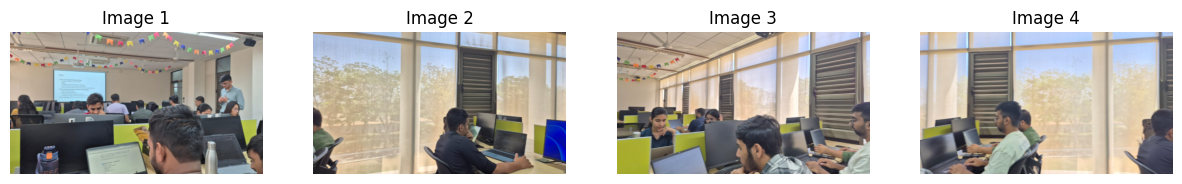

In [12]:
plt.figure(figsize=(15,5))
for i,img in enumerate(images[:4]):
    plt.subplot(1,len(images[:4]),i+1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}")
    plt.axis("off")
plt.show()


Manual Panorama

Stitching image 1
Matches: 7
Homography failed

Stitching image 2
Matches: 9
Homography failed

Stitching image 3
Matches: 5
Homography failed

Stitching image 4
Matches: 16

Stitching image 5
Matches: 10

Stitching image 6
Matches: 7
Homography failed

Stitching image 7
Matches: 39

Stitching image 8
Matches: 56

Stitching image 9
Matches: 14

Stitching image 10
Matches: 18

Stitching image 11
Matches: 49

Stitching image 12
Matches: 9
Homography failed

Stitching image 13
Matches: 26

Stitching image 14
Matches: 5
Homography failed

Stitching image 15
Matches: 11

Stitching image 16
Matches: 10

Stitching image 17
Matches: 9
Homography failed

Stitching image 18
Matches: 6
Homography failed

Stitching image 19
Matches: 9
Homography failed

Stitching image 20
Matches: 7
Homography failed

Stitching image 21
Matches: 18

Stitching image 22
Matches: 90

Stitching image 23
Matches: 12

Stitching image 24
Matches: 52

Stitching image 25
Matches: 12

Stitching image 26
Ma

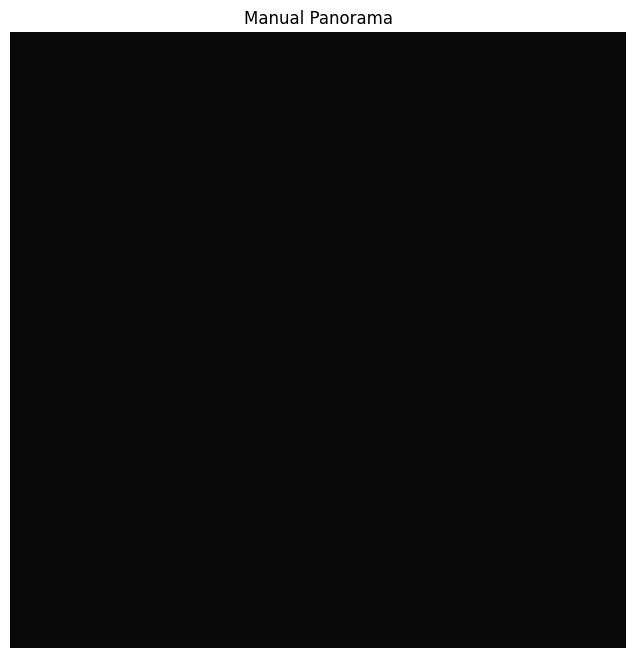

In [13]:
print("\nManual Panorama")
manual = stitch_all(images)
plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(manual,cv2.COLOR_BGR2RGB))
plt.title("Manual Panorama")
plt.axis("off")
plt.show()


OpenCV Automatic Stitcher


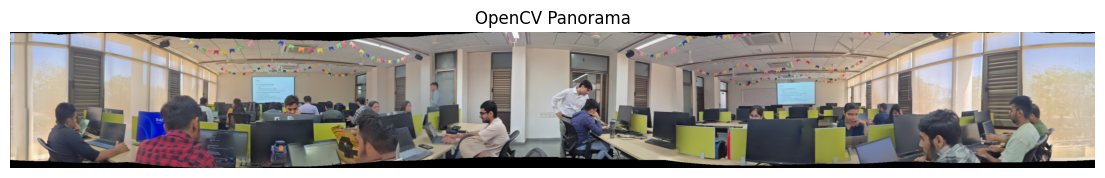


Done.


In [14]:
print("\nOpenCV Automatic Stitcher")
stitcher = cv2.Stitcher_create()
status,pano = stitcher.stitch(images)
if status == cv2.Stitcher_OK:
    plt.figure(figsize=(14,8))
    plt.imshow(cv2.cvtColor(pano,cv2.COLOR_BGR2RGB))
    plt.title("OpenCV Panorama")
    plt.axis("off")
    plt.show()
else:
    print("Stitching failed:",status)
print("\nDone.")